In [1]:
import pandas as pd

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


# Get all SAS files in the data folder
data_folder = '../data/'
sas_files = sorted([f for f in os.listdir(data_folder) if f.endswith('.sas7bdat')])

print(f"Found {len(sas_files)} SAS files:")
for file in sas_files:
    print(f"  - {file}")

# Load all SAS files and combine them
dfs = []
for file in sas_files:
    file_path = os.path.join(data_folder, file)
    print(f"\nLoading {file}...")
    df_temp = pd.read_sas(file_path)
    print(f"  Shape: {df_temp.shape}")
    print(f"  Columns: {list(df_temp.columns)}")
    dfs.append(df_temp)

# Combine all dataframes
df = pd.concat(dfs, ignore_index=True)

print(f"\n{'='*60}")
print(f"COMBINED DATASET")
print(f"{'='*60}")
print(f"Total Shape: {df.shape}")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()


Found 1 SAS files:
  - ed2022_sas.sas7bdat

Loading ed2022_sas.sas7bdat...
  Shape: (16025, 913)
  Columns: ['VMONTH', 'VDAYR', 'ARRTIME', 'WAITTIME', 'LOV', 'AGE', 'AGER', 'AGEDAYS', 'RESIDNCE', 'SEX', 'ETHUN', 'ETHIM', 'RACEUN', 'RACER', 'RACERETH', 'ARREMS', 'AMBTRANSFER', 'NOPAY', 'PAYPRIV', 'PAYMCARE', 'PAYMCAID', 'PAYWKCMP', 'PAYSELF', 'PAYNOCHG', 'PAYOTH', 'PAYDK', 'PAYTYPER', 'TEMPF', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT', 'IMMEDR', 'PAINSCALE', 'SEEN72', 'RFV1', 'RFV2', 'RFV3', 'RFV4', 'RFV5', 'RFV13D', 'RFV23D', 'RFV33D', 'RFV43D', 'RFV53D', 'EPISODE', 'INJURY', 'INJPOISAD', 'INJURY72', 'INTENT15', 'INJURY_ENC', 'CAUSE1', 'CAUSE2', 'CAUSE3', 'DIAG1', 'DIAG2', 'DIAG3', 'DIAG4', 'DIAG5', 'PRDIAG1', 'PRDIAG2', 'PRDIAG3', 'PRDIAG4', 'PRDIAG5', 'ETOHAB', 'ALZHD', 'ASTHMA', 'CANCER', 'CEBVD', 'CKD', 'COPD', 'CHF', 'CAD', 'DEPRN', 'DIABTYP1', 'DIABTYP2', 'DIABTYP0', 'ESRD', 'HPE', 'EDHIV', 'HYPLIPID', 'HTN', 'OBESITY', 'OSA', 'OSTPRSIS', 'SUBSTAB', 'NOCHRON', 'TOTCHRON', 'DIA

,VMONTH,VDAYR,ARRTIME,WAITTIME,LOV,AGE,AGER,AGEDAYS,RESIDNCE,SEX,...,RX30V3C2,RX30V3C3,RX30V3C4,SETTYPE,YEAR,CSTRATM,CPSUM,PATWT,EDWT,BOARDED
0,9.0,2.0,b'0604',10.0,228.0,23.0,2.0,-7.0,1.0,1.0,...,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,8.36413,-7.0
1,9.0,2.0,b'1053',40.0,319.0,15.0,2.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,NaN,-7.0
2,9.0,2.0,b'1419',70.0,551.0,19.0,2.0,-7.0,1.0,2.0,...,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,NaN,-7.0
3,9.0,2.0,b'1825',-7.0,-9.0,0.0,1.0,298.0,1.0,2.0,...,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,NaN,-7.0
4,9.0,2.0,b'2243',14.0,168.0,18.0,2.0,-7.0,1.0,1.0,...,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,NaN,-7.0


In [27]:
# Dataset Overview
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (109760, 1061)

Column Names and Data Types:
VMONTH              float64
VDAYR               float64
ARRTIME              object
WAITTIME            float64
LOV                 float64
                     ...   
BLANK3              float64
BLANK4              float64
COVID_VALIDATION    float64
COVIDTEST           float64
COVIDANTIBODY       float64
Length: 1061, dtype: object

Missing Values:
VMONTH                   0
VDAYR                    0
ARRTIME                  0
WAITTIME                 0
LOV                  36176
                     ...  
BLANK3              109760
BLANK4              109760
COVID_VALIDATION     93553
COVIDTEST            93735
COVIDANTIBODY        93735
Length: 1061, dtype: int64


In [5]:
# Convert ARRTIME to proper time format (HH:MM)
def convert_arrtime_to_time(arr_time):
    """
    Convert ARRTIME from byte format (e.g., b'0604') to time format (HH:MM)
    b'0604' -> '06:04'
    b'1419' -> '14:19'
    """
    try:
        if pd.isna(arr_time):
            return pd.NaT
        
        # Convert bytes to string if needed
        if isinstance(arr_time, bytes):
            time_str = arr_time.decode('utf-8')
        else:
            time_str = str(arr_time)
        
        # Handle cases where time is already in correct format or is missing
        if len(time_str) < 4:
            return pd.NaT
        
        # Extract hours and minutes (last 4 digits)
        hours = time_str[-4:-2]
        minutes = time_str[-2:]
        
        # Create time string in HH:MM format
        time_formatted = f"{hours}:{minutes}"
        
        # Convert to datetime.time object
        return pd.to_datetime(time_formatted, format='%H:%M').time()
    except:
        return pd.NaT

# Apply conversion
df['ARRTIME'] = df['ARRTIME'].apply(convert_arrtime_to_time)

print("ARRTIME conversion complete!")
print("\nSample converted ARRTIME values:")
print(df['ARRTIME'].head(20))
print(f"\nData type: {df['ARRTIME'].dtype}")
print(f"\nMissing values: {df['ARRTIME'].isna().sum()}")



ARRTIME conversion complete!

Sample converted ARRTIME values:
0     06:04:00
1     10:53:00
2     14:19:00
3     18:25:00
4     22:43:00
5     09:03:00
6     14:28:00
7     18:30:00
8     05:32:00
9     16:38:00
10    21:48:00
11    10:14:00
12    15:04:00
13    19:03:00
14    12:25:00
15    17:13:00
16    23:09:00
17    08:41:00
18    13:12:00
19    18:13:00
Name: ARRTIME, dtype: object

Data type: object

Missing values: 243


In [8]:
# Extract column descriptions from NHAMCS documentation PDF
import pdfplumber
import pandas as pd
import re

pdf_path = '../data/doc21-ed-508.pdf'

# Extract text and tables from PDF
try:
    with pdfplumber.open(pdf_path) as pdf:
        print(f"Total pages in PDF: {len(pdf.pages)}\n")
        
        # Extract all text
        full_text = ""
        for page in pdf.pages:
            full_text += page.extract_text()
        
        # Try to find column/variable definitions
        print("Looking for column definitions in the documentation...\n")
        
        # Search for common patterns in variable documentation
        lines = full_text.split('\n')
        
        # Find variable definitions (usually start with a variable name followed by description)
        variables = {}
        current_var = None
        
        for i, line in enumerate(lines):
            # Look for lines that might contain variable definitions
            if re.match(r'^[A-Z]{2,}', line.strip()) and len(line.strip()) < 50:
                current_var = line.strip()
                if i + 1 < len(lines):
                    variables[current_var] = lines[i + 1].strip()
        
        print(f"Found {len(variables)} potential variables")
        print("\nSample variables and descriptions:")
        for var, desc in list(variables.items())[:20]:
            print(f"{var}: {desc[:70]}...")
        
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Total pages in PDF: 266

Looking for column definitions in the documentation...

Found 325 potential variables

Sample variables and descriptions:
ABSTRACT: This material provides documentation for users of the Emergency Depart...
SUMMARY OF CHANGES FOR 2021: A. Survey Items...
PATIENT VISIT WEIGHT: Micro-data file users should be fully aware of the importance of the "...
RELIABILITY OF ESTIMATES: Researchers should also be aware of the reliability or unreliability o...
PSU sample design is available (5).: 2. Hospitals...
NONRESPONSE: VARIABLE VARIABLE DESCRIPTION DENOMINATOR...
VARIABLE VARIABLE DESCRIPTION DENOMINATOR: %...
WAITTIME in minutes was made 12.0: RACEUN Unimputed race All visits 21.4...
RACEUN Unimputed race All visits 21.4: ETHUN Unimputed ethnicity All visits 14.4...
ETHUN Unimputed ethnicity All visits 14.4: Was the patient transferred...
AMBTRANSFER care facility? ambulance 17.3: Recoded primary expected...
TEMPF (Fahrenheit) All visits 6.5: Initial vital signs: Heart

In [9]:
# Build a comprehensive data dictionary from PDF and current dataframe columns
column_descriptions = {
    # Temporal Variables
    'VMONTH': 'Month of visit',
    'VDAYR': 'Day of week of visit',
    'ARRTIME': 'Arrival time (formatted)',
    'WAITTIME': 'Time from arrival to seeing provider (minutes)',
    'LOV': 'Length of visit (minutes)',
    'BOARDED': 'Number of hours patient remained in ED after decision to admit',
    
    # Demographics
    'AGE': 'Age of patient in years',
    'AGER': 'Age group',
    'AGEDAYS': 'Age in days for pediatric patients',
    'SEX': 'Sex of patient (1=Male, 2=Female)',
    'ETHUN': 'Ethnicity - unimputed (1=Non-Hispanic, 2=Hispanic)',
    'RACEUN': 'Race - unimputed',
    'RESIDNCE': 'Residence area (1=Metropolitan, 2=Micropolitan, 3=Non-core)',
    
    # Clinical Variables
    'TRIAGE': 'Triage acuity level',
    'PAINSCALE': 'Pain scale score (0-10)',
    'TEMPF': 'Temperature in Fahrenheit',
    'PULSE': 'Heart rate (beats per minute)',
    'RESPR': 'Respiratory rate per minute',
    'BPSYS': 'Blood pressure - Systolic',
    'BPDIAS': 'Blood pressure - Diastolic',
    'POPCT': 'Pulse oximetry (percent)',
    
    # Resource Utilization
    'IMAG': 'Imaging ordered',
    'CT': 'CT scan ordered',
    'MRI': 'MRI ordered',
    'XRAY': 'X-ray ordered',
    'ULTRASOUND': 'Ultrasound ordered',
    'LABTEST': 'Laboratory test ordered',
    'MEDORTO': 'Medication ordered/provided at ED',
    
    # Hospital Operations
    'SETTYPE': 'Type of facility (hospital/freestanding)',
    'YEAR': 'Year of data collection',
    'EDWT': 'Probability weight for ED',
    'PATWT': 'Patient sampling weight',
}

# Get all columns from the dataframe
all_columns = df.columns.tolist()

# Create a DataFrame with column information
column_info = []
for col in all_columns:
    description = column_descriptions.get(col, 'See NHAMCS documentation')
    data_type = str(df[col].dtype)
    non_missing = df[col].notna().sum()
    missing_pct = (df[col].isna().sum() / len(df)) * 100
    
    column_info.append({
        'Column_Name': col,
        'Data_Type': data_type,
        'Non_Missing': non_missing,
        'Missing_%': f"{missing_pct:.1f}%",
        'Description': description
    })

column_dict_df = pd.DataFrame(column_info)

print("="*100)
print("COMPLETE DATA DICTIONARY - ED 2022 DATASET (from NHAMCS)")
print("="*100)
print(f"\nTotal columns: {len(column_dict_df)}")
print(f"Total rows: {len(df)}\n")

# Display by category
print("\n" + "="*100)
print("TEMPORAL VARIABLES")
print("="*100)
temporal_display = column_dict_df[column_dict_df['Column_Name'].isin(['VMONTH', 'VDAYR', 'ARRTIME', 'WAITTIME', 'LOV', 'BOARDED'])]
print(temporal_display.to_string(index=False))

print("\n" + "="*100)
print("DEMOGRAPHIC VARIABLES")
print("="*100)
demo_display = column_dict_df[column_dict_df['Column_Name'].isin(['AGE', 'AGER', 'AGEDAYS', 'SEX', 'ETHUN', 'RACEUN', 'RESIDNCE'])]
print(demo_display.to_string(index=False))

print("\n" + "="*100)
print("CLINICAL VARIABLES")
print("="*100)
clinical_display = column_dict_df[column_dict_df['Column_Name'].isin(['TRIAGE', 'PAINSCALE', 'TEMPF', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT'])]
print(clinical_display.to_string(index=False))

print("\n" + "="*100)
print("ALL COLUMNS - FULL DATA DICTIONARY")
print("="*100)
print(column_dict_df.to_string(index=False))

COMPLETE DATA DICTIONARY - ED 2022 DATASET (from NHAMCS)

Total columns: 913
Total rows: 16025


TEMPORAL VARIABLES
Column_Name Data_Type  Non_Missing Missing_%                                                    Description
     VMONTH   float64        16025      0.0%                                                 Month of visit
      VDAYR   float64        16025      0.0%                                           Day of week of visit
    ARRTIME    object        15782      1.5%                                       Arrival time (formatted)
   WAITTIME   float64        16025      0.0%                 Time from arrival to seeing provider (minutes)
        LOV   float64        16025      0.0%                                      Length of visit (minutes)
    BOARDED   float64        16025      0.0% Number of hours patient remained in ED after decision to admit

DEMOGRAPHIC VARIABLES
Column_Name Data_Type  Non_Missing Missing_%                                                 Description


In [10]:
# Split columns into thematic dataframes for analysis
from collections import OrderedDict

# Define core groups (explicit + keyword-based fallbacks)
groups = OrderedDict({
    "temporal": {
        "explicit": ["VMONTH", "VDAYR", "ARRTIME", "WAITTIME", "LOV", "BOARDED"],
        "keywords": ["time", "month", "day", "arrival", "wait", "los", "lov", "board", "hour", "minute"]
    },
    "demographics": {
        "explicit": ["AGE", "AGER", "AGEDAYS", "SEX", "ETHUN", "RACEUN", "RESIDNCE"],
        "keywords": ["age", "sex", "gender", "race", "ethnicity", "ethn", "resid", "payer", "insur"]
    },
    "clinical": {
        "explicit": ["TRIAGE", "PAINSCALE", "TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"],
        "keywords": ["triage", "pain", "vital", "temp", "pulse", "resp", "bp", "ox", "diagn", "injur"]
    },
    "resources": {
        "explicit": ["IMAG", "CT", "MRI", "XRAY", "ULTRASOUND", "LABTEST", "MEDORTO"],
        "keywords": ["imag", "ct", "mri", "xray", "ultra", "lab", "test", "proc"]
    },
    "operations": {
        "explicit": ["SETTYPE", "YEAR", "EDWT", "PATWT"],
        "keywords": ["settype", "edwt", "patwt", "weight", "volume", "bed", "capacity", "fast", "track", "protocol"]
    },
})

# Helper to collect existing columns

def collect_columns(explicit, keywords):
    cols = []
    for c in explicit:
        if c in df.columns:
            cols.append(c)
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            cols.append(c)
    seen = set()
    unique_cols = []
    for c in cols:
        if c not in seen:
            seen.add(c)
            unique_cols.append(c)
    return unique_cols

# Build dataframes
df_temporal = df[collect_columns(groups["temporal"]["explicit"], groups["temporal"]["keywords"])].copy()
df_demographics = df[collect_columns(groups["demographics"]["explicit"], groups["demographics"]["keywords"])].copy()
df_clinical = df[collect_columns(groups["clinical"]["explicit"], groups["clinical"]["keywords"])].copy()
df_resources = df[collect_columns(groups["resources"]["explicit"], groups["resources"]["keywords"])].copy()
df_operations = df[collect_columns(groups["operations"]["explicit"], groups["operations"]["keywords"])].copy()

# Summary
summary = pd.DataFrame({
    "dataframe": ["df_temporal", "df_demographics", "df_clinical", "df_resources", "df_operations"],
    "rows": [len(df_temporal), len(df_demographics), len(df_clinical), len(df_resources), len(df_operations)],
    "columns": [df_temporal.shape[1], df_demographics.shape[1], df_clinical.shape[1], df_resources.shape[1], df_operations.shape[1]]
})

print("Created thematic dataframes:")
print(summary.to_string(index=False))

# Show a few columns from each for validation
print("\nSample columns:")
print("Temporal:", list(df_temporal.columns[:12]))
print("Demographics:", list(df_demographics.columns[:12]))
print("Clinical:", list(df_clinical.columns[:12]))
print("Resources:", list(df_resources.columns[:12]))
print("Operations:", list(df_operations.columns[:12]))




Created thematic dataframes:
      dataframe  rows  columns
    df_temporal 16025       11
df_demographics 16025       16
    df_clinical 16025       19
   df_resources 16025       24
  df_operations 16025        9

Sample columns:
Temporal: ['VMONTH', 'VDAYR', 'ARRTIME', 'WAITTIME', 'LOV', 'BOARDED', 'AGEDAYS', 'LOS', 'BOARD', 'BOARDHOS', 'SURGDAY']
Demographics: ['AGE', 'AGER', 'AGEDAYS', 'SEX', 'ETHUN', 'RACEUN', 'RESIDNCE', 'RACER', 'RACERETH', 'ANYIMAGE', 'OTHIMAGE', 'AGEFL']
Clinical: ['PAINSCALE', 'TEMPF', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT', 'INJURY', 'INJURY72', 'INJURY_ENC', 'TOXSCREN', 'BPAP']
Resources: ['MRI', 'XRAY', 'POPCT', 'ELECTROL', 'LACTATE', 'HIVTEST', 'FLUTEST', 'PREGTEST', 'OTHRTEST', 'ANYIMAGE', 'CTCONTRAST', 'CTAB']
Operations: ['SETTYPE', 'YEAR', 'EDWT', 'PATWT', 'BEDREG', 'IMBED', 'FASTTRAK', 'BEDCZAR', 'BEDDATA']


In [11]:
df_temporal.info()
df_demographics.info()
df_clinical.info()
df_resources.info()
df_operations.info()

print("first 5 rows of temporal:")
print(df_temporal.head())

print("first 5 rows of demographics:")
print(df_demographics.head())       

print("first 5 rows of clinical:")
print(df_clinical.head())

print("first 5 rows of resources:")
print(df_resources.head())  

print("first 5 rows of operations:")
print(df_operations.head()) 

<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   VMONTH    16025 non-null  float64
 1   VDAYR     16025 non-null  float64
 2   ARRTIME   15782 non-null  object 
 3   WAITTIME  16025 non-null  float64
 4   LOV       16025 non-null  float64
 5   BOARDED   16025 non-null  float64
 6   AGEDAYS   16025 non-null  float64
 7   LOS       16025 non-null  float64
 8   BOARD     16025 non-null  float64
 9   BOARDHOS  16025 non-null  float64
 10  SURGDAY   16025 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.3+ MB
<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       16025 non-null  float64
 1   AGER      16025 non-null  float64
 2   AGEDAYS   16025 non-null  float64
 3   SEX       16025 non-null  float64
 4   ETHUN

In [12]:
# Drop AGEDAYS from df_temporal
df_temporal = df_temporal.drop(columns=['AGEDAYS'], errors='ignore')


In [13]:
# Combining all columns from the thematic dataframes to create a comprehensive dataframe for analysis
df_all = pd.concat([df_temporal, df_demographics, df_clinical, df_resources, df_operations], axis=1)
df_all.info()
df_all.drop(columns=['MUSTAGE1', 'MUSTAGE2', ], errors='ignore', inplace=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 78 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VMONTH        16025 non-null  float64
 1   VDAYR         16025 non-null  float64
 2   ARRTIME       15782 non-null  object 
 3   WAITTIME      16025 non-null  float64
 4   LOV           16025 non-null  float64
 5   BOARDED       16025 non-null  float64
 6   LOS           16025 non-null  float64
 7   BOARD         16025 non-null  float64
 8   BOARDHOS      16025 non-null  float64
 9   SURGDAY       16025 non-null  float64
 10  AGE           16025 non-null  float64
 11  AGER          16025 non-null  float64
 12  AGEDAYS       16025 non-null  float64
 13  SEX           16025 non-null  float64
 14  ETHUN         16025 non-null  float64
 15  RACEUN        16025 non-null  float64
 16  RESIDNCE      16025 non-null  float64
 17  RACER         16025 non-null  float64
 18  RACERETH      16025 non-null  float64

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [16]:
#load and combine the data

data_folder = "../data/"

sas_files = sorted([f for f in os.listdir(data_folder) if f.endswith(".sas7bdat")])

print(f"Found {len(sas_files)} SAS files:")
for f in sas_files:
    print(" -", f)

dfs = []
for file in sas_files:
    file_path = os.path.join(data_folder, file)
    print(f"\nLoading {file} ...")
    temp_df = pd.read_sas(file_path, format="sas7bdat")
    print("Shape:", temp_df.shape)
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True, sort=False)

print("\nCombined dataset shape:", df.shape)
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("\nFirst 5 rows:")
display(df.head())



Found 1 SAS files:
 - ed2022_sas.sas7bdat

Loading ed2022_sas.sas7bdat ...
Shape: (16025, 913)

Combined dataset shape: (16025, 913)
Total rows: 16025
Total columns: 913

First 5 rows:


,VMONTH,VDAYR,ARRTIME,WAITTIME,LOV,AGE,AGER,AGEDAYS,RESIDNCE,SEX,ETHUN,ETHIM,RACEUN,RACER,RACERETH,ARREMS,AMBTRANSFER,NOPAY,PAYPRIV,PAYMCARE,PAYMCAID,PAYWKCMP,PAYSELF,PAYNOCHG,PAYOTH,PAYDK,PAYTYPER,TEMPF,PULSE,RESPR,BPSYS,BPDIAS,POPCT,IMMEDR,PAINSCALE,SEEN72,RFV1,RFV2,RFV3,RFV4,RFV5,RFV13D,RFV23D,RFV33D,RFV43D,RFV53D,EPISODE,INJURY,INJPOISAD,INJURY72,INTENT15,INJURY_ENC,CAUSE1,CAUSE2,CAUSE3,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,PRDIAG1,PRDIAG2,PRDIAG3,PRDIAG4,PRDIAG5,ETOHAB,ALZHD,ASTHMA,CANCER,CEBVD,CKD,COPD,CHF,CAD,DEPRN,DIABTYP1,DIABTYP2,DIABTYP0,ESRD,HPE,EDHIV,HYPLIPID,HTN,OBESITY,OSA,OSTPRSIS,SUBSTAB,NOCHRON,TOTCHRON,DIAGSCRN,ABG,BAC,BMP,BNP,BUNCREAT,CARDENZ,CBC,CMP,BLOODCX,TRTCX,...,RX26CAT4,RX26V1C1,RX26V1C2,RX26V1C3,RX26V1C4,RX26V2C1,RX26V2C2,RX26V2C3,RX26V2C4,RX26V3C1,RX26V3C2,RX26V3C3,RX26V3C4,DRUGID27,PRESCR27,CONTSUB27,COMSTAT27,RX27CAT1,RX27CAT2,RX27CAT3,RX27CAT4,RX27V1C1,RX27V1C2,RX27V1C3,RX27V1C4,RX27V2C1,RX27V2C2,RX27V2C3,RX27V2C4,RX27V3C1,RX27V3C2,RX27V3C3,RX27V3C4,DRUGID28,PRESCR28,CONTSUB28,COMSTAT28,RX28CAT1,RX28CAT2,RX28CAT3,RX28CAT4,RX28V1C1,RX28V1C2,RX28V1C3,RX28V1C4,RX28V2C1,RX28V2C2,RX28V2C3,RX28V2C4,RX28V3C1,RX28V3C2,RX28V3C3,RX28V3C4,DRUGID29,PRESCR29,CONTSUB29,COMSTAT29,RX29CAT1,RX29CAT2,RX29CAT3,RX29CAT4,RX29V1C1,RX29V1C2,RX29V1C3,RX29V1C4,RX29V2C1,RX29V2C2,RX29V2C3,RX29V2C4,RX29V3C1,RX29V3C2,RX29V3C3,RX29V3C4,DRUGID30,PRESCR30,CONTSUB30,COMSTAT30,RX30CAT1,RX30CAT2,RX30CAT3,RX30CAT4,RX30V1C1,RX30V1C2,RX30V1C3,RX30V1C4,RX30V2C1,RX30V2C2,RX30V2C3,RX30V2C4,RX30V3C1,RX30V3C2,RX30V3C3,RX30V3C4,SETTYPE,YEAR,CSTRATM,CPSUM,PATWT,EDWT,BOARDED
0,9.0,2.0,b'0604',10.0,228.0,23.0,2.0,-7.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-8.0,984.0,72.0,16.0,104.0,66.0,72.0,3.0,-8.0,2.0,15451.0,-9.0,-9.0,-9.0,-9.0,1545.0,0.0,0.0,0.0,0.0,2.0,1.0,3.0,-9.0,-9.0,1.0,b'-9',b'-9',b'-9',b'T833',b'-9',b'-9',b'-9',b'-9',0.0,-7.0,-7.0,-7.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,8.36413,-7.0
1,9.0,2.0,b'1053',40.0,319.0,15.0,2.0,-7.0,1.0,2.0,2.0,2.0,3.0,3.0,4.0,-9.0,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-8.0,983.0,67.0,18.0,105.0,67.0,96.0,-9.0,-9.0,-9.0,15250.0,15300.0,-9.0,-9.0,-9.0,1525.0,1530.0,0.0,0.0,0.0,1.0,0.0,4.0,-9.0,-9.0,-9.0,b'-9',b'-9',b'-9',b'K297',b'R110',b'-9',b'-9',b'-9',0.0,0.0,-7.0,-7.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2022.0,20122201.0,100001.0,3665.56954,NaN,-7.0
2,9.0,2.0,b'1419',70.0,551.0,19.0,2.0,-7.0,1.0,2.0,1.0,1.0,-9.0,1.0,3.0,2.0,-7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-9.0,987.0,79.0,21.0,144.0,82.0,79.0,3.0,-8.0,2.0,12601.0,13050.0,12250.0,-9.0,-9.0,1260.0,1305.0,1225.0,0.0,0.0,1.0,0.0,4.0,-9.0,-9.0,-9.0,b'-9',b'-9',b'-9',b'R000',b'-9',b'-9',b'-9',b'-9',0.0,-7.0,-7.0,-7.0,-7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [17]:
# Focus on variables related to wait time EDA and your proposal.
candidate_cols = [
    "WAITTIME",   # target
    "ARRTIME",
    "VMONTH",
    "VDAYR",
    "AGE",
    "SEX",
    "RACEUN",
    "ETHUN",
    "IMMEDR",
    "PAINSCALE",
    "LOV",
    "ADMIT",
    "FASTTRAK",
    "OBSCLIN",
    "BOARD",
    "BPSYS",
    "BPDIAS",
    "TEMPF",
    "PULSE",
    "RESPR",
    "POPCT",
]

existing_cols = [col for col in candidate_cols if col in df.columns]
missing_cols = [col for col in candidate_cols if col not in df.columns]

print("\nExisting relevant columns:")
print(existing_cols)

print("\nRequested columns not found:")
print(missing_cols)

eda_df = df[existing_cols].copy()
print("\nEDA dataframe shape:", eda_df.shape)


Existing relevant columns:
['WAITTIME', 'ARRTIME', 'VMONTH', 'VDAYR', 'AGE', 'SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'PAINSCALE', 'LOV', 'ADMIT', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT']

Requested columns not found:
[]

EDA dataframe shape: (16025, 21)


In [18]:
#helper function to convert ARRTIME to HH:MM format
def convert_arrtime_to_time(arr_time):
    """
    Convert ARRTIME from values like b'0604' to a pandas time-like string HH:MM.
    Returns pd.NaT on invalid values.
    """
    try:
        if pd.isna(arr_time):
            return pd.NaT

        if isinstance(arr_time, bytes):
            time_str = arr_time.decode("utf-8")
        else:
            time_str = str(arr_time)

        # Keep only digits just in case
        time_str = "".join(ch for ch in time_str if ch.isdigit())

        if len(time_str) == 3:
            time_str = "0" + time_str

        if len(time_str) != 4:
            return pd.NaT

        hh = int(time_str[:2])
        mm = int(time_str[2:])

        if hh < 0 or hh > 23 or mm < 0 or mm > 59:
            return pd.NaT

        return pd.to_datetime(f"{hh:02d}:{mm:02d}", format="%H:%M").time()

    except Exception:
        return pd.NaT

# Apply conversion if ARRTIME exists
if "ARRTIME" in eda_df.columns:
    eda_df["ARRTIME_CLEAN"] = eda_df["ARRTIME"].apply(convert_arrtime_to_time)
    eda_df["ARRIVAL_HOUR"] = eda_df["ARRTIME_CLEAN"].apply(
        lambda x: x.hour if pd.notnull(x) else np.nan
    )


In [19]:
# Basic cleaning steps for EDA

print("\nBEFORE CLEANING ")
print("Rows:", len(eda_df))

# Drop rows where WAITTIME is missing, since it is the target variable
if "WAITTIME" in eda_df.columns:
    eda_df = eda_df.dropna(subset=["WAITTIME"])

# Remove negative wait times if present
if "WAITTIME" in eda_df.columns:
    eda_df = eda_df[eda_df["WAITTIME"] >= 0]

# Optional: cap extreme outliers for cleaner EDA display only
# We keep a separate plotting version so the original cleaned data stays intact.
plot_df = eda_df.copy()
if "WAITTIME" in plot_df.columns:
    upper_cap = plot_df["WAITTIME"].quantile(0.99)
    plot_df["WAITTIME_CAPPED"] = plot_df["WAITTIME"].clip(upper=upper_cap)

# Fill some numeric missing values with median for EDA convenience
numeric_fill_cols = ["AGE", "PAINSCALE", "BPSYS", "BPDIAS", "TEMPF", "PULSE", "RESPR", "POPCT", "LOV"]
for col in numeric_fill_cols:
    if col in eda_df.columns:
        eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")
        median_val = eda_df[col].median()
        eda_df[col] = eda_df[col].fillna(median_val)

if "ARRIVAL_HOUR" in eda_df.columns:
    eda_df["ARRIVAL_HOUR"] = pd.to_numeric(eda_df["ARRIVAL_HOUR"], errors="coerce")

if "WAITTIME" in eda_df.columns:
    eda_df["WAITTIME"] = pd.to_numeric(eda_df["WAITTIME"], errors="coerce")

# Clean categorical fields if present
categorical_cols = ["SEX", "RACEUN", "ETHUN", "IMMEDR", "ADMIT", "FASTTRAK", "OBSCLIN", "BOARD", "VDAYR", "VMONTH"]
for col in categorical_cols:
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].astype("category")

print("\n AFTER CLEANING")
print("Rows:", len(eda_df))
print("\nMissing values after cleaning:")
display(eda_df.isnull().sum().sort_values(ascending=False))


BEFORE CLEANING 
Rows: 16025

 AFTER CLEANING
Rows: 13272

Missing values after cleaning:


WAITTIME         0
ARRTIME          0
VMONTH           0
VDAYR            0
AGE              0
SEX              0
RACEUN           0
ETHUN            0
IMMEDR           0
PAINSCALE        0
LOV              0
ADMIT            0
FASTTRAK         0
OBSCLIN          0
BOARD            0
BPSYS            0
BPDIAS           0
TEMPF            0
PULSE            0
RESPR            0
POPCT            0
ARRTIME_CLEAN    0
ARRIVAL_HOUR     0
dtype: int64

In [ ]:
#check for duplicates and inconsistencies
print("\nDUPLICATE CHECK ")
duplicate_rows = eda_df.duplicated().sum()
print("Number of duplicate rows in EDA dataframe:", duplicate_rows)

eda_df = eda_df.drop_duplicates()
plot_df = eda_df.copy()

if "WAITTIME" in plot_df.columns:
    # Cap extreme outliers for plotting
    upper_cap = plot_df["WAITTIME"].quantile(0.99)
    plot_df["WAITTIME_CAPPED"] = plot_df["WAITTIME"].clip(upper=upper_cap)

print("Rows after dropping duplicates:", len(eda_df))



DUPLICATE CHECK 
Number of duplicate rows in EDA dataframe: 21
Rows after dropping duplicates: 13251


In [22]:
print("\nSUMMARY STATISTICS")

summary_cols = [col for col in ["WAITTIME", "AGE", "PAINSCALE", "LOV", "BPSYS", "BPDIAS", "TEMPF", "PULSE", "RESPR", "POPCT"] if col in eda_df.columns]
display(eda_df[summary_cols].describe().T)

if "WAITTIME" in eda_df.columns:
    print("\nWait Time Mean:", eda_df["WAITTIME"].mean())
    print("Wait Time Median:", eda_df["WAITTIME"].median())
    print("Wait Time Std:", eda_df["WAITTIME"].std())


SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
WAITTIME,13251.0,36.006264,65.518467,0.0,5.0,14.0,38.0,1280.0
AGE,13251.0,40.668176,25.071617,0.0,20.0,39.0,61.0,94.0
PAINSCALE,13251.0,-0.775640,6.866358,-9.0,-8.0,0.0,6.0,10.0
LOV,13251.0,296.288356,418.909230,-9.0,110.0,189.0,321.0,5722.0
BPSYS,13251.0,122.413025,46.448714,-9.0,113.0,129.0,146.0,289.0
BPDIAS,13251.0,71.592182,29.704210,-9.0,66.0,77.0,87.0,998.0
TEMPF,13251.0,947.194476,184.640323,-9.0,977.0,981.0,986.0,1053.0
PULSE,13251.0,93.420647,75.908143,-9.0,75.0,88.0,102.0,998.0
RESPR,13251.0,18.980002,7.965642,-9.0,17.0,18.0,20.0,150.0
POPCT,13251.0,93.309033,20.981691,-9.0,96.0,98.0,99.0,100.0



Wait Time Mean: 36.00626367821297
Wait Time Median: 14.0
Wait Time Std: 65.5184666349674


In [23]:
print("\n GROUPED SUMMARIES")

if "ARRIVAL_HOUR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    wait_by_hour = eda_df.groupby("ARRIVAL_HOUR", observed=False)["WAITTIME"].agg(["count", "mean", "median"]).reset_index()
    print("\nWait time by arrival hour:")
    display(wait_by_hour)

if "VDAYR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    wait_by_day = eda_df.groupby("VDAYR", observed=False)["WAITTIME"].agg(["count", "mean", "median"]).reset_index()
    print("\nWait time by day of week:")
    display(wait_by_day)

if "IMMEDR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    wait_by_triage = eda_df.groupby("IMMEDR", observed=False)["WAITTIME"].agg(["count", "mean", "median"]).reset_index()
    print("\nWait time by triage urgency:")
    display(wait_by_triage)

if "SEX" in eda_df.columns and "WAITTIME" in eda_df.columns:
    wait_by_sex = eda_df.groupby("SEX", observed=False)["WAITTIME"].agg(["count", "mean", "median"]).reset_index()
    print("\nWait time by sex:")
    display(wait_by_sex)



 GROUPED SUMMARIES

Wait time by arrival hour:


,ARRIVAL_HOUR,count,mean,median
0,0.0,311,38.954984,11.0
1,1.0,311,42.212219,13.0
2,2.0,243,30.954733,11.0
3,3.0,212,39.834906,11.0
4,4.0,220,35.195455,13.0
5,5.0,196,31.306122,12.5
6,6.0,288,26.520833,10.0
7,7.0,352,26.480114,10.0
8,8.0,559,22.926655,10.0
9,9.0,702,29.431624,13.0



Wait time by day of week:


,VDAYR,count,mean,median
0,1.0,1711,33.055523,14.0
1,2.0,2158,37.641798,15.0
2,3.0,1985,38.254912,16.0
3,4.0,1955,40.052685,15.0
4,5.0,1875,34.016000,14.0
5,6.0,1884,36.305202,14.0
6,7.0,1683,31.439097,13.0



Wait time by triage urgency:


,IMMEDR,count,mean,median
0,-9.0,151,39.695364,11.0
1,-8.0,3129,36.972515,13.0
2,0.0,424,44.886792,18.0
3,1.0,112,24.946429,9.5
4,2.0,1354,28.541359,12.0
5,3.0,4521,37.531962,15.0
6,4.0,2382,35.409740,15.0
7,5.0,263,30.756654,13.0
8,7.0,915,35.901639,19.0



Wait time by sex:


,SEX,count,mean,median
0,1.0,7054,36.871279,15.0
1,2.0,6197,35.021623,14.0


In [24]:
print("\n CORRELATION MATRIX ")

corr_cols = [col for col in ["WAITTIME", "AGE", "PAINSCALE", "LOV", "BPSYS", "BPDIAS", "TEMPF", "PULSE", "RESPR", "POPCT", "ARRIVAL_HOUR"] if col in eda_df.columns]
corr_df = eda_df[corr_cols].apply(pd.to_numeric, errors="coerce")

display(corr_df.corr())


 CORRELATION MATRIX 


,WAITTIME,AGE,PAINSCALE,LOV,BPSYS,BPDIAS,TEMPF,PULSE,RESPR,POPCT,ARRIVAL_HOUR
WAITTIME,1.000000,-0.027883,-0.025750,0.154407,0.003722,0.014838,0.030848,0.052379,0.021853,0.012131,0.030774
AGE,-0.027883,1.000000,0.094106,0.128695,0.483194,0.348188,-0.045150,-0.088552,-0.180629,0.010189,-0.059901
PAINSCALE,-0.025750,0.094106,1.000000,-0.036896,0.199831,0.201677,0.098560,0.056393,-0.045905,0.135625,0.001037
LOV,0.154407,0.128695,-0.036896,1.000000,0.072980,0.049696,-0.007521,-0.021197,-0.005370,0.014953,0.000785
BPSYS,0.003722,0.483194,0.199831,0.072980,1.000000,0.860384,0.201757,-0.055797,-0.083003,0.224204,-0.035989
BPDIAS,0.014838,0.348188,0.201677,0.049696,0.860384,1.000000,0.198074,0.002192,-0.075783,0.212236,-0.032935
TEMPF,0.030848,-0.045150,0.098560,-0.007521,0.201757,0.198074,1.000000,0.111228,0.284709,0.350208,-0.006656
PULSE,0.052379,-0.088552,0.056393,-0.021197,-0.055797,0.002192,0.111228,1.000000,0.336556,0.039959,-0.011443
RESPR,0.021853,-0.180629,-0.045905,-0.005370,-0.083003,-0.075783,0.284709,0.336556,1.000000,0.226354,0.001087
POPCT,0.012131,0.010189,0.135625,0.014953,0.224204,0.212236,0.350208,0.039959,0.226354,1.000000,0.018199


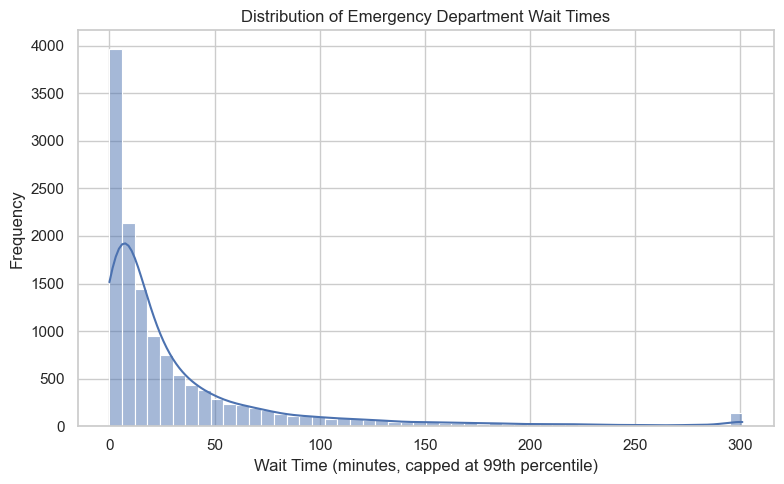

In [25]:
#visualization 1 wait time distribution

if "WAITTIME_CAPPED" in plot_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(plot_df["WAITTIME_CAPPED"], bins=50, kde=True)
    plt.title("Distribution of Emergency Department Wait Times")
    plt.xlabel("Wait Time (minutes, capped at 99th percentile)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

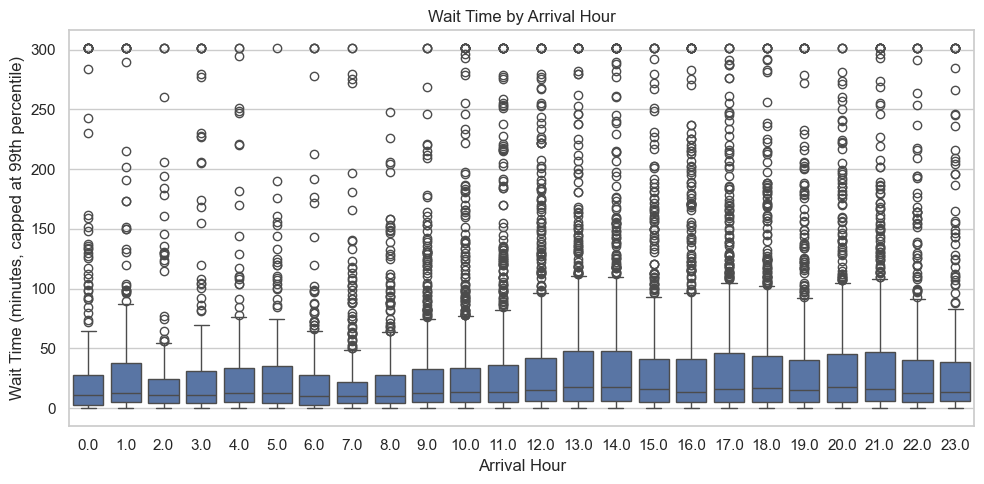

In [26]:
#visualization 2 waittime by arrival hour

if "ARRIVAL_HOUR" in plot_df.columns and "WAITTIME_CAPPED" in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=plot_df, x="ARRIVAL_HOUR", y="WAITTIME_CAPPED")
    plt.title("Wait Time by Arrival Hour")
    plt.xlabel("Arrival Hour")
    plt.ylabel("Wait Time (minutes, capped at 99th percentile)")
    plt.tight_layout()
    plt.show()


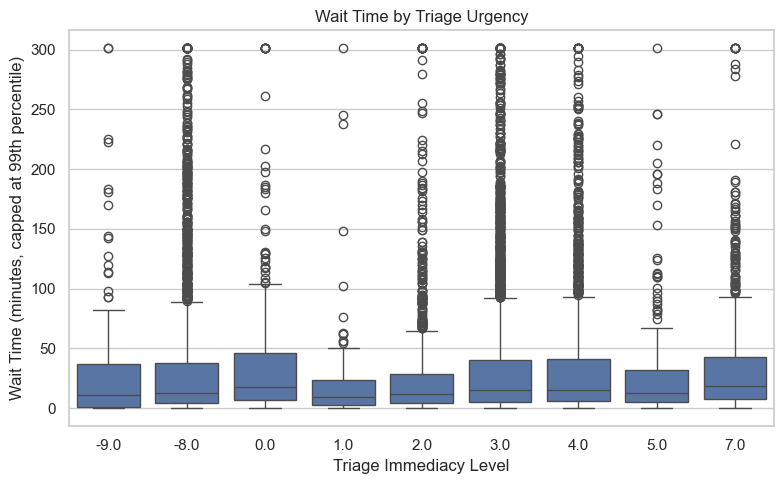

In [27]:
#VISUALIZATION 3: WAIT TIME BY TRIAGE LEVEL
if "IMMEDR" in plot_df.columns and "WAITTIME_CAPPED" in plot_df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=plot_df, x="IMMEDR", y="WAITTIME_CAPPED")
    plt.title("Wait Time by Triage Urgency")
    plt.xlabel("Triage Immediacy Level")
    plt.ylabel("Wait Time (minutes, capped at 99th percentile)")
    plt.tight_layout()
    plt.show()

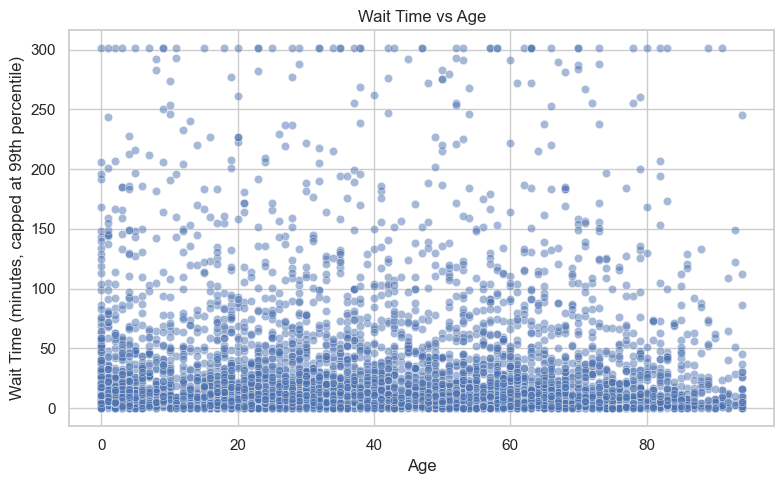

In [28]:
# VISUALIZATION 4: wait time vs age scatter plot
if "AGE" in plot_df.columns and "WAITTIME_CAPPED" in plot_df.columns:
    sample_plot_df = plot_df[["AGE", "WAITTIME_CAPPED"]].dropna()
    if len(sample_plot_df) > 5000:
        sample_plot_df = sample_plot_df.sample(5000, random_state=42)

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=sample_plot_df, x="AGE", y="WAITTIME_CAPPED", alpha=0.5)
    plt.title("Wait Time vs Age")
    plt.xlabel("Age")
    plt.ylabel("Wait Time (minutes, capped at 99th percentile)")
    plt.tight_layout()
    plt.show()


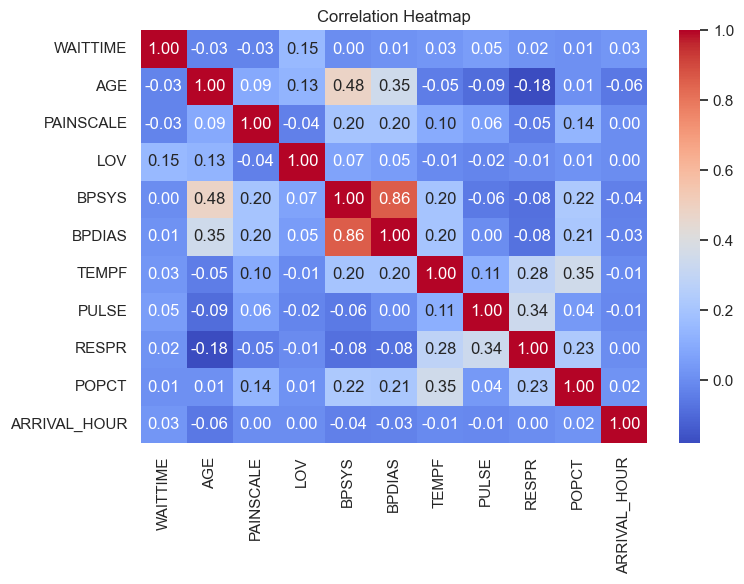

In [29]:
#VISUALIZATION 5:correlation heatmap
if len(corr_cols) >= 2:
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

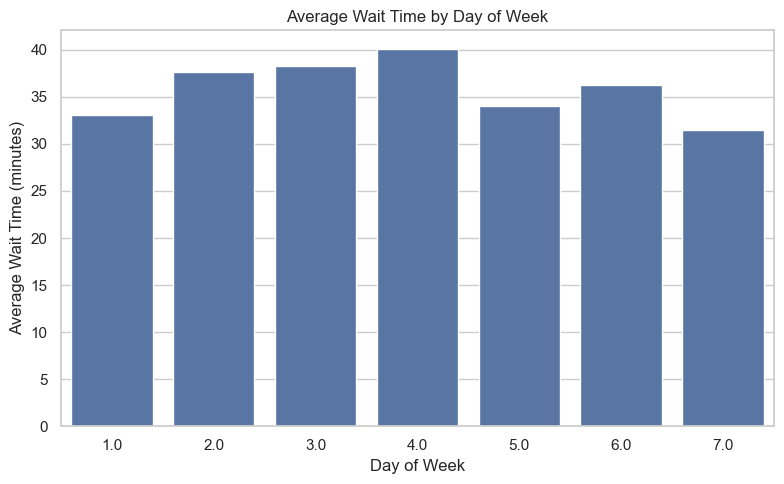

In [30]:
#visualization 6: average wait time by day of week
if "VDAYR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    day_summary = eda_df.groupby("VDAYR", observed=False)["WAITTIME"].mean().reset_index()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=day_summary, x="VDAYR", y="WAITTIME")
    plt.title("Average Wait Time by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Wait Time (minutes)")
    plt.tight_layout()
    plt.show()

In [ ]:
#eda insights
print("\n EDA insights:")

insights = []

if "WAITTIME" in eda_df.columns:
    insights.append(
        f"Overall wait times are right-skewed, with a mean of {eda_df['WAITTIME'].mean():.2f} minutes "
        f"and a median of {eda_df['WAITTIME'].median():.2f} minutes"
    )

if "ARRIVAL_HOUR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    hour_means = eda_df.groupby("ARRIVAL_HOUR", observed=False)["WAITTIME"].mean()
    if len(hour_means.dropna()) > 0:
        peak_hour = hour_means.idxmax()
        peak_value = hour_means.max()
        insights.append(
            f"Average wait times appear highest around arrival hour {peak_hour}, "
            f"where the mean wait time is {peak_value:.2f} minutes"
        )

if "IMMEDR" in eda_df.columns and "WAITTIME" in eda_df.columns:
    triage_means = eda_df.groupby("IMMEDR", observed=False)["WAITTIME"].mean().dropna()
    if len(triage_means) > 0:
        insights.append(
            "Wait times vary across triage urgency levels, suggesting patient severity is related to how quickly patients are seen"
        )

if "LOV" in eda_df.columns and "WAITTIME" in eda_df.columns:
    corr_val = eda_df[["WAITTIME", "LOV"]].corr().iloc[0, 1]
    insights.append(
        f"WAITTIME and LOV show a correlation of {corr_val:.2f}, suggesting that longer waits may be associated with longer total ED stays"
    )

if "AGE" in eda_df.columns and "WAITTIME" in eda_df.columns:
    insights.append(
        "Age may have some relationship with wait time, but the strength and direction should be interpreted more carefully after modeling"
    )

for i, item in enumerate(insights, start=1):
    print(f"{i}. {item}")


 EDA insights:
1. Overall wait times are right-skewed, with a mean of 36.01 minutes and a median of 14.00 minutes
2. Average wait times appear highest around arrival hour 1.0, where the mean wait time is 42.21 minutes
3. Wait times vary across triage urgency levels, suggesting patient severity is related to how quickly patients are seen
4. WAITTIME and LOV show a correlation of 0.15, suggesting that longer waits may be associated with longer total ED stays
5. Age may have some relationship with wait time, but the strength and direction should be interpreted more carefully after modeling


: 